In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import duckdb

In [4]:
df = pd.read_csv(r"C:\Users\Top Prix\OneDrive\New folder\cleaning_data\messy_practice_data.csv")

In [5]:
df.head()

,customer_id,name,age,salary,signup_date,city,product,quantity,satisfaction_score
0,C1088,Hiro O'Neil,29.1,"$44,959",04-23-2025,Mumbai,Doohickey,7.0,82.0
1,C1022,Bob O'Neil,58.7,"$63,776",13 Sep 2024,Tokyo,Gizmo,2.0,60.4
2,C1060,Jamal Müller,51.9,"$74,685",11-29-2024,Tokyo,Gizmo,8.0,-999.0
3,C1234,Elena Nguyen,39.2,"$81,096",2025-10-13,Lisbon,Gizmo,NaN,67.9
4,C1199,Jamal Kowalski,24.3,"$58,309",2024-04-06,Austin,Sprocket,4.0,56.7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         263 non-null    object 
 1   name                263 non-null    object 
 2   age                 248 non-null    float64
 3   salary              247 non-null    object 
 4   signup_date         260 non-null    object 
 5   city                258 non-null    object 
 6   product             263 non-null    object 
 7   quantity            252 non-null    float64
 8   satisfaction_score  263 non-null    float64
dtypes: float64(3), object(6)
memory usage: 18.6+ KB


In [7]:
df.isna().sum()

customer_id            0
name                   0
age                   15
salary                16
signup_date            3
city                   5
product                0
quantity              11
satisfaction_score     0
dtype: int64

one column at a time, starting with age

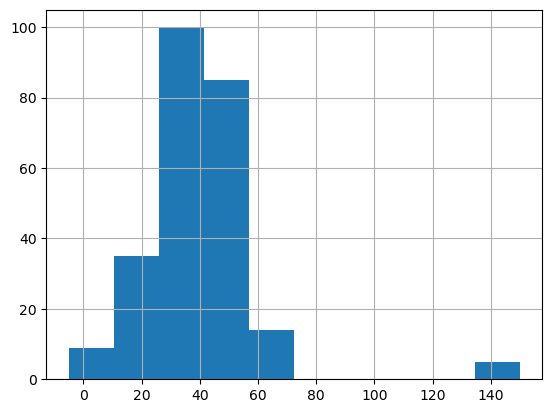

In [8]:
df["age"].hist()
plt.show()

In [9]:
df.loc[df["age"] > 100 , "age"] = np.nan
df.loc[df["age"] < 18 ,  "age"] = np.nan


In [10]:
df["age"].fillna(df["age"].mean() , inplace = True)

C:\Users\Top Prix\AppData\Local\Temp\ipykernel_6720\3635198819.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].mean() , inplace = True)


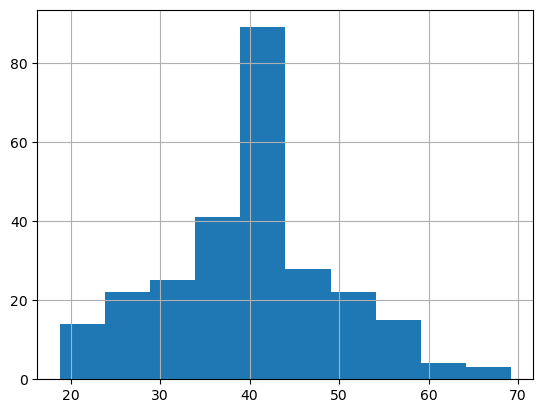

In [11]:
df["age"].hist()
plt.show()

salary


In [12]:
df["salary"].head()

0    $44,959
1    $63,776
2    $74,685
3    $81,096
4    $58,309
Name: salary, dtype: object

In [13]:
df["salary"] = df["salary"].str.replace("$" , "").str.replace("," , "")

In [14]:
df["salary"].unique()

array(['44959', '63776', '74685', '81096', '58309', '86825', '75018',
       '93997', '48805', '46629', '48756', '76513', '77630', '69903', nan,
       '58838', '41913', '76252', '78733', '70336', '46729', '68193',
       '79000', '53846', '23234', '91121', '95273', '57375', '61380',
       '63565', '45318', '71979', '64782', '70653', '33051', '44477',
       '59848', '74441', '63432', '41552', '44848', '61865', '73066',
       '64754', '62792', '18835', '62281', '62444', '51437', '68095',
       '21570', '63531', '72966', '32839', '98261', '43114', '46419',
       '50119', '89051', '50481', '54604', '69235', '59613', '33848',
       '56741', '67959', '42494', '48610', '87531', '21621', '76437',
       '58928', '65921', '79127', '42600', '53248', '71288', '89311',
       '77849', '30137', '51220', '94000', '41941', '67846', '44186',
       '57591', 'unknown', '97357', '96122', '87463', '39373', '110888',
       '72146', '46445', '?', '42997', '76655', '101878', '100951',
       '91971'

In [15]:
df["salary"] = pd.to_numeric(df["salary"] , errors = 'coerce')

In [16]:
print(f"max salary is : {df["salary"].max()}")
print(f"min salary is {df["salary"].min()}")

max salary is : 110888.0
min salary is 18835.0


In [17]:
df['salary'] = df['salary'].fillna(df['salary'].mean())

City column


In [18]:
df["city"].unique()

array(['Mumbai', 'Tokyo', 'Lisbon', 'Austin', nan, 'Nairobi', 'Berlin',
       'Sydney', 'Toronto', 'Lisbonn', 'BERLIN', 'Berlin ', 'berlin'],
      dtype=object)

In [19]:
df["city"] = df["city"].str.capitalize().str.strip()

In [20]:
df["city"] = df["city"].replace({"Lisbonn" : "Lisbon"})

In [21]:
df["city"].unique()

array(['Mumbai', 'Tokyo', 'Lisbon', 'Austin', nan, 'Nairobi', 'Berlin',
       'Sydney', 'Toronto'], dtype=object)

In [22]:
df.dropna(subset="city", inplace = True)

signup date


In [23]:
df["signup_date"].unique()

array(['04-23-2025', '13 Sep 2024', '11-29-2024', '2025-10-13',
       '2024-04-06', '28/07/2025', '2025-05-04', '2025-11-25',
       '30/07/2025', '13 Aug 2024', '11-13-2025', '2024-10-23',
       '07-06-2024', '03/06/2024', '13 Jun 2024', '12/05/2025',
       '07-15-2024', '07/07/2025', '06-17-2024', '11-10-2024',
       '26/09/2025', '03-01-2024', '19 Jun 2024', '2024-04-19',
       '25 Jun 2024', '2024-10-07', '19 Jan 2024', '06/01/2025',
       '08-02-2025', '17 Apr 2024', '01-16-2025', '26 Jun 2025',
       '2024-07-21', '02/06/2024', '2024-03-15', '2025-02-14',
       '2024-03-23', '27/03/2025', '11-20-2024', '03-13-2025',
       '18 Jun 2025', '2024-06-23', '05/03/2024', '31 Aug 2024',
       'not a date', '2024-07-20', '07-21-2024', '2024-07-26',
       '01/01/2024', '08/06/2025', '2025-10-30', '2025-08-01',
       '04-15-2025', '15/02/2025', '11/07/2025', '08-01-2024',
       '01/04/2025', '12/07/2025', '03-19-2024', '03-18-2025',
       '05/06/2024', '05 May 2024', '26/05/20

In [24]:
#df2=duckdb.sql("").df()

In [25]:
df["signup_date"] = pd.to_datetime(df["signup_date"] , format = 'mixed' , errors ='coerce').dt.date

In [26]:
df["signup_date"].unique()

array([datetime.date(2025, 4, 23), datetime.date(2024, 9, 13),
       datetime.date(2024, 11, 29), datetime.date(2025, 10, 13),
       datetime.date(2024, 4, 6), datetime.date(2025, 7, 28),
       datetime.date(2025, 5, 4), datetime.date(2025, 11, 25),
       datetime.date(2025, 7, 30), datetime.date(2024, 8, 13),
       datetime.date(2025, 11, 13), datetime.date(2024, 10, 23),
       datetime.date(2024, 7, 6), datetime.date(2024, 3, 6),
       datetime.date(2024, 6, 13), datetime.date(2025, 12, 5),
       datetime.date(2024, 7, 15), datetime.date(2025, 7, 7),
       datetime.date(2024, 6, 17), datetime.date(2024, 11, 10),
       datetime.date(2025, 9, 26), datetime.date(2024, 3, 1),
       datetime.date(2024, 6, 19), datetime.date(2024, 4, 19),
       datetime.date(2024, 6, 25), datetime.date(2024, 10, 7),
       datetime.date(2024, 1, 19), datetime.date(2025, 6, 1),
       datetime.date(2025, 8, 2), datetime.date(2024, 4, 17),
       datetime.date(2025, 1, 16), datetime.date(2025, 6,

In [27]:
df["signup_date"] = df["signup_date"].fillna(method = 'ffill')

C:\Users\Top Prix\AppData\Local\Temp\ipykernel_6720\475419288.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["signup_date"] = df["signup_date"].fillna(method = 'ffill')


In [28]:
df["signup_date"].isna().sum()

np.int64(0)

Quantity

In [29]:
df["quantity"].value_counts()

quantity
8.0       37
3.0       32
4.0       29
5.0       26
9.0       25
2.0       25
6.0       24
1.0       23
7.0       22
9999.0     4
Name: count, dtype: int64

In [30]:
#wild assumption but lets say 9999 was supposed to be 9
df.loc[df["quantity"]==9999.0 , "quantity"] = 9.0

In [31]:
df["quantity"].isna().sum()

np.int64(11)

In [32]:
df["quantity"].fillna(df["quantity"].mean(), inplace = True )

C:\Users\Top Prix\AppData\Local\Temp\ipykernel_6720\2904873203.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["quantity"].fillna(df["quantity"].mean(), inplace = True )


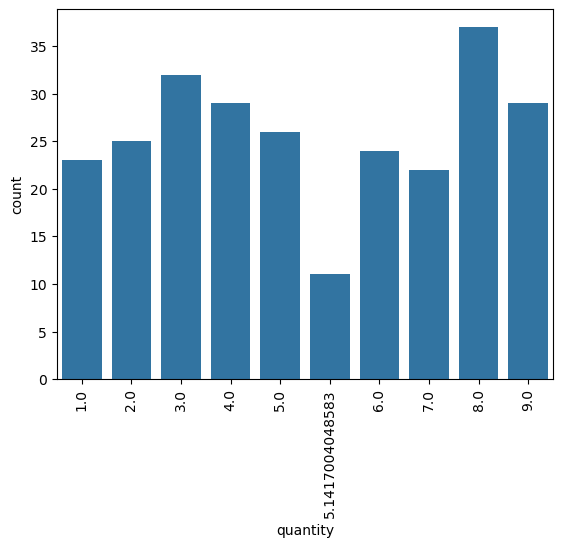

In [33]:
sns.countplot(data = df , x = 'quantity')
plt.xticks(rotation = 90,)
plt.show()

In [34]:
df["quantity"] = round(df['quantity'], 0).astype('int')

Satisfaction Score

In [35]:
df["satisfaction_score"].value_counts()

satisfaction_score
-999.0    8
 87.4     4
 55.2     3
 68.5     3
 68.1     3
         ..
 28.2     1
 72.9     1
 60.0     1
 71.2     1
 70.0     1
Name: count, Length: 194, dtype: int64

<Axes: >

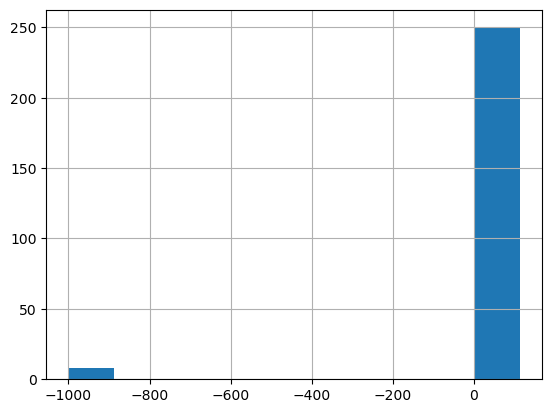

In [36]:
df["satisfaction_score"].hist()

In [37]:
df["satisfaction_score"]=np.where(df["satisfaction_score"] <  0 , np.nan , df["satisfaction_score"])

<Axes: >

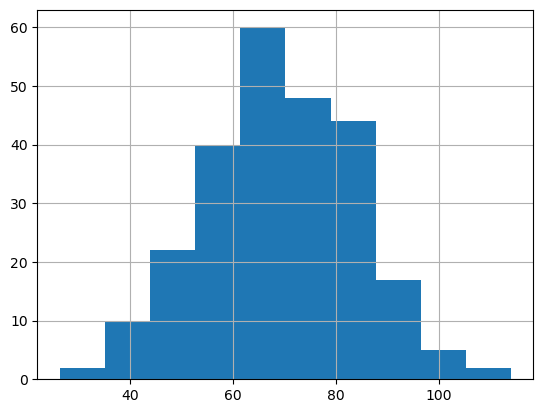

In [38]:
df["satisfaction_score"].hist()

In [39]:
df["satisfaction_score"] = np.where(df['satisfaction_score'] > 100 , np.nan , df['satisfaction_score'])

In [40]:
df['satisfaction_score'].isna().sum()

np.int64(11)

In [41]:
df["satisfaction_score"] = df["satisfaction_score"].fillna(df['satisfaction_score'].mean())

<Axes: >

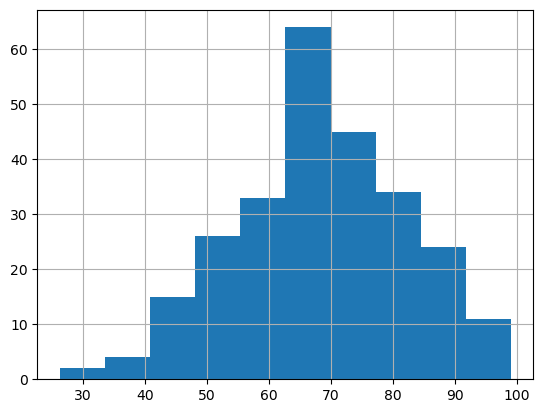

In [42]:
df['satisfaction_score'].hist()

In [43]:
df.drop_duplicates(keep = 'first', inplace= True)

Product

In [44]:
df['product'].unique()

array(['Doohickey', 'Gizmo', 'Sprocket', 'Widget', 'Gadget', 'widg et',
       'widget', 'Gadjet', 'gizmo'], dtype=object)

In [45]:
df['product'] = df['product'].str.strip().str.capitalize()

In [46]:
df['product'].unique()

array(['Doohickey', 'Gizmo', 'Sprocket', 'Widget', 'Gadget', 'Widg et',
       'Gadjet'], dtype=object)

In [47]:
df['product'] = df['product'].replace({"Gadjet" : "Gadget"})

In [48]:
df['product'] = df['product'].replace({"Widg et": "Widget"})

In [49]:
df['product'].unique()

array(['Doohickey', 'Gizmo', 'Sprocket', 'Widget', 'Gadget'], dtype=object)

Name

In [50]:
df['name'] = df['name'].str.strip().str.title()

now let me check the curated dataset

In [51]:
df.to_csv('cleaned_dataset.csv')

In [52]:
df.describe()

,age,salary,quantity,satisfaction_score
count,247.000000,247.000000,247.000000,247.000000
mean,39.957868,63642.147840,5.113360,68.557757
std,9.678338,17850.767050,2.560508,14.048360
min,18.800000,18835.000000,1.000000,26.300000
25%,34.400000,51068.500000,3.000000,58.900000
50%,39.891480,64044.119835,5.000000,68.569636
75%,45.050000,74874.500000,8.000000,79.150000
max,69.200000,110888.000000,9.000000,99.100000


In [53]:
bins = [0, 30000, 70000, np.inf]
label = ['low wage', 'working class', 'high earners']

df['category'] = pd.cut(df['salary'], bins=bins, labels=label)


In [54]:
df.groupby("category")['quantity'].count()

C:\Users\Top Prix\AppData\Local\Temp\ipykernel_6720\3547041507.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("category")['quantity'].count()


category
low wage           7
working class    156
high earners      84
Name: quantity, dtype: int64

In [55]:
df.groupby('category').agg(satisfaction_average = ('satisfaction_score','mean'))

C:\Users\Top Prix\AppData\Local\Temp\ipykernel_6720\1767581976.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('category').agg(satisfaction_average = ('satisfaction_score','mean'))


,satisfaction_average
category,
low wage,67.224234
working class,68.514217
high earners,68.749745


In [56]:
df.groupby('product')['quantity'].sum().sort_values(ascending = False)

product
Gizmo        313
Gadget       252
Widget       241
Doohickey    232
Sprocket     225
Name: quantity, dtype: int64

In [57]:
df2 = duckdb.sql("select customer_id , sum(quantity) as total_orders from df group by customer_id order by total_orders desc ").df()

In [58]:
df2.head()

,customer_id,total_orders
0,C1245,9.0
1,C1047,9.0
2,C1160,9.0
3,C1032,9.0
4,C1222,9.0
